# 🚀 Web3 Trader Behavior Insights: Sentiment vs. Performance
### Primetrade.ai — Python Development Intern Assignment
**Author:** Data Science Intern Applicant  
**Date:** March 20, 2026  
**Data:** Hyperliquid Historical Trades + Bitcoin Fear & Greed Index

---
## 🧭 Project Objective
> **Can market sentiment predict trader performance on a decentralized exchange?**

This notebook systematically uncovers patterns between the **Bitcoin Fear & Greed Index** 
and the actual trading performance of real traders on **Hyperliquid**, a leading DEX. 
We aim to derive actionable insights that can meaningfully improve trading strategies.

## 1. 📦 Setup & Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Global styling — dark, polished, professional
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#ccccdd',
    'text.color': '#ccccdd',
    'xtick.color': '#aaaacc',
    'ytick.color': '#aaaacc',
    'grid.color': '#2a2d3a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.titlecolor': '#e0e0f0',
    'figure.titlesize': 18,
    'figure.titleweight': 'bold',
    'legend.facecolor': '#1a1d27',
    'legend.edgecolor': '#444466',
    'legend.labelcolor': '#ccccdd',
})

SENTIMENT_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
SENTIMENT_COLORS = {
    'Extreme Fear':  '#ef4444',
    'Fear':          '#f97316',
    'Neutral':       '#a3a3a3',
    'Greed':         '#22c55e',
    'Extreme Greed': '#10b981',
}
PALETTE  = [SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER]

print("✅ Libraries loaded and style configured.")

✅ Libraries loaded and style configured.


## 2. 🗂️ Data Loading & Overview

In [2]:
df_trades    = pd.read_csv('historical_data.csv')
df_sentiment = pd.read_csv('fear_greed_index.csv')

print("=== Historical Trader Data (Hyperliquid) ===")
print(f"Shape: {df_trades.shape}")
print(df_trades.dtypes)
print()
df_trades.head(3)

=== Historical Trader Data (Hyperliquid) ===
Shape: (211224, 16)
Account                 str
Coin                    str
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                    str
Timestamp IST           str
Start Position      float64
Direction               str
Closed PnL          float64
Transaction Hash        str
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object



,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


In [3]:
print("=== Fear & Greed Index ===")
print(f"Shape: {df_sentiment.shape}")
print(df_sentiment.dtypes)
print()
df_sentiment.head(3)

=== Fear & Greed Index ===
Shape: (2644, 4)
timestamp         int64
value             int64
classification      str
date                str
dtype: object



,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03


## 3. 🔧 Data Cleaning & Merging
We align both datasets on a common `Date` column (YYYY-MM-DD) and perform an inner join so
every trade record carries that day's sentiment classification.

In [4]:
# Parse dates
df_trades['Date']    = pd.to_datetime(df_trades['Timestamp IST'],
                                       format='%d-%m-%Y %H:%M',
                                       errors='coerce').dt.strftime('%Y-%m-%d')
df_sentiment['Date'] = df_sentiment['date']

# Inner join on Date
df = pd.merge(df_trades, df_sentiment, on='Date', how='inner')

# Derived fields
df['Is_Win']  = df['Closed PnL'] > 0
df['Is_Loss'] = df['Closed PnL'] < 0
df['Date_dt'] = pd.to_datetime(df['Date'])

# Sanity-check
print(f"Total trades after merge : {len(df):>10,}")
print(f"Date range               : {df['Date'].min()}  →  {df['Date'].max()}")
print(f"Unique trading accounts  : {df['Account'].nunique():>10,}")
print(f"Unique coins             : {df['Coin'].nunique():>10,}")
missing = df.isnull().sum()
print(f"\nMissing values:\n{missing[missing > 0].to_string() if missing.any() else '  None — clean dataset ✅'}")

Total trades after merge :    211,218
Date range               : 2023-05-01  →  2025-05-01


Unique trading accounts  :         32
Unique coins             :        246

Missing values:
  None — clean dataset ✅


## 4. 📊 Sentiment Distribution in the Dataset
Before diving in, understand how many trading days fall under each sentiment zone.

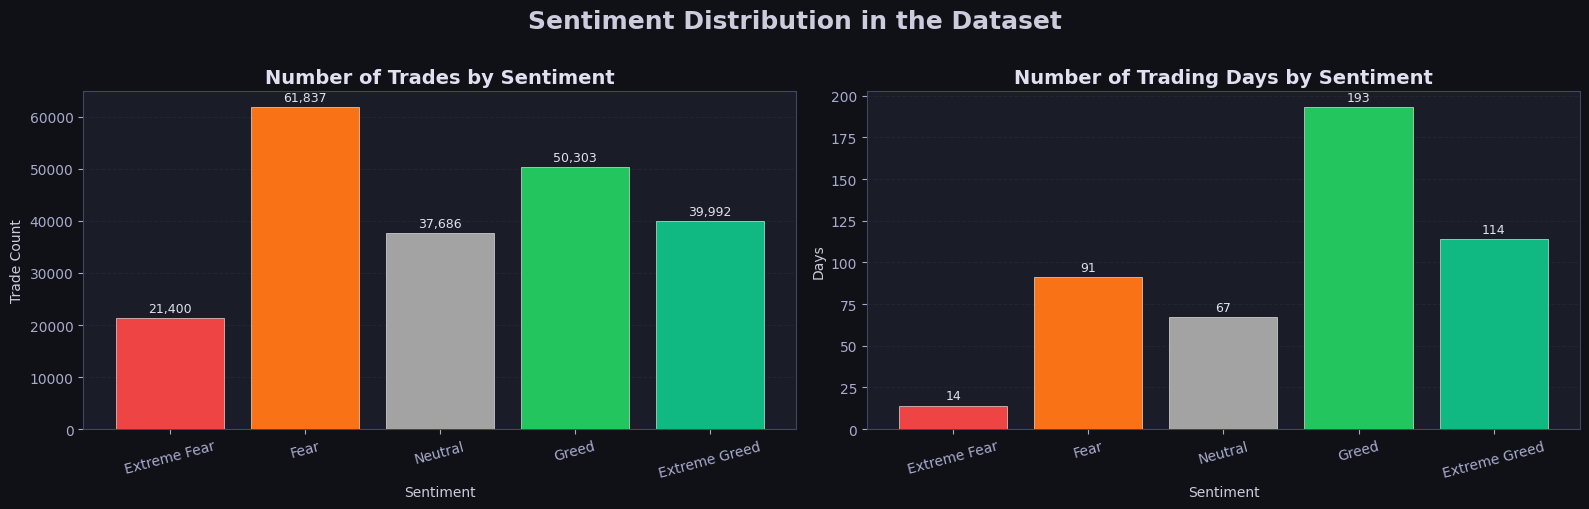

In [5]:
# Trade count per sentiment
sent_counts = df.groupby('classification').size().reindex(SENTIMENT_ORDER).reset_index()
sent_counts.columns = ['Sentiment', 'Trade Count']

# Unique days per sentiment
days_per_sent = (df.drop_duplicates('Date')
                   .groupby('classification').size()
                   .reindex(SENTIMENT_ORDER)
                   .reset_index())
days_per_sent.columns = ['Sentiment', 'Days']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Sentiment Distribution in the Dataset', y=1.01)

for ax, data, col, title in [
    (axes[0], sent_counts, 'Trade Count', 'Number of Trades by Sentiment'),
    (axes[1], days_per_sent, 'Days',       'Number of Trading Days by Sentiment'),
]:
    bars = ax.bar(data['Sentiment'], data[col],
                  color=[SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER],
                  edgecolor='white', linewidth=0.4, zorder=3)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + data[col].max() * 0.01,
                f'{bar.get_height():,.0f}',
                ha='center', va='bottom', fontsize=9, color='#e0e0f0')
    ax.set_title(title)
    ax.set_xlabel('Sentiment')
    ax.set_ylabel(col)
    ax.set_xticks(range(len(SENTIMENT_ORDER)))
    ax.set_xticklabels(SENTIMENT_ORDER, rotation=15)
    ax.grid(axis='y', zorder=0)

plt.tight_layout()
plt.show()

## 5. 💰 Profitability vs. Sentiment
### 5.1 Average PnL & Win Rate per Sentiment Bucket

In [6]:
# Aggregate
pnl_agg = (df.groupby('classification')['Closed PnL']
             .agg(Total_PnL='sum', Avg_PnL='mean', Trade_Count='count')
             .reindex(SENTIMENT_ORDER).reset_index())

win_rate = (df.groupby('classification')['Is_Win']
              .mean()
              .reindex(SENTIMENT_ORDER)
              .reset_index()
              .rename(columns={'Is_Win': 'Win_Rate'}))
win_rate['Win_Rate_Pct'] = win_rate['Win_Rate'] * 100

# Display table
summary = pnl_agg.merge(win_rate, on='classification')
summary.rename(columns={'classification': 'Sentiment'}, inplace=True)
print(summary[['Sentiment', 'Trade_Count', 'Total_PnL', 'Avg_PnL', 'Win_Rate_Pct']].to_string(index=False))

    Sentiment  Trade_Count    Total_PnL   Avg_PnL  Win_Rate_Pct
 Extreme Fear        21400 7.391102e+05 34.537862     37.060748
         Fear        61837 3.357155e+06 54.290400     42.076750
      Neutral        37686 1.292921e+06 34.307718     39.699093
        Greed        50303 2.150129e+06 42.743559     38.482794
Extreme Greed        39992 2.715171e+06 67.892861     46.494299


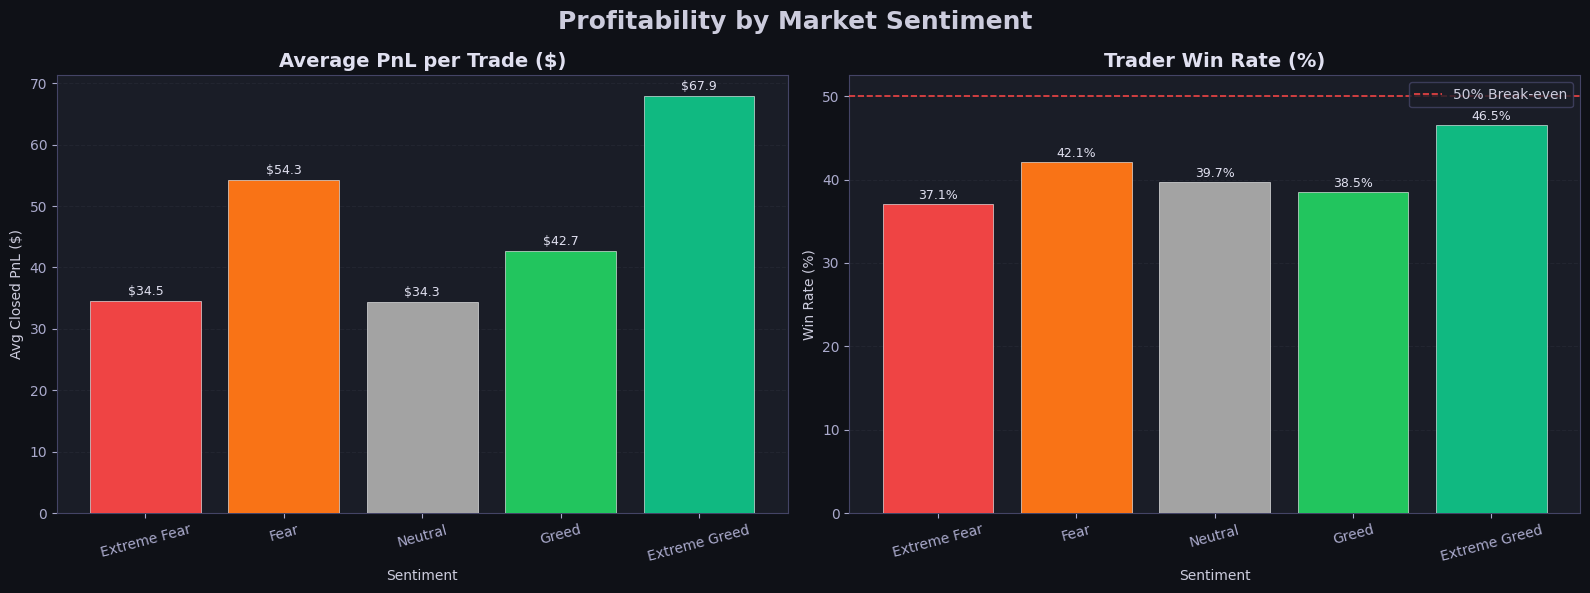

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Profitability by Market Sentiment')

# Avg PnL
bars1 = axes[0].bar(SENTIMENT_ORDER, pnl_agg['Avg_PnL'],
                    color=PALETTE, edgecolor='white', linewidth=0.4, zorder=3)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'${bar.get_height():,.1f}',
                 ha='center', va='bottom', fontsize=9, color='#e0e0f0')
axes[0].set_title('Average PnL per Trade ($)')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Avg Closed PnL ($)')
axes[0].set_xticklabels(SENTIMENT_ORDER, rotation=15)
axes[0].grid(axis='y', zorder=0)

# Win Rate
bars2 = axes[1].bar(SENTIMENT_ORDER, win_rate['Win_Rate_Pct'],
                    color=PALETTE, edgecolor='white', linewidth=0.4, zorder=3)
axes[1].axhline(50, color='#ef4444', linestyle='--', linewidth=1.2, label='50% Break-even', zorder=4)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%',
                 ha='center', va='bottom', fontsize=9, color='#e0e0f0')
axes[1].set_title('Trader Win Rate (%)')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_xticklabels(SENTIMENT_ORDER, rotation=15)
axes[1].legend()
axes[1].grid(axis='y', zorder=0)

plt.tight_layout()
plt.show()

> ### 🔍 Key Insight #1 — The Extreme Greed Alpha
> **Extreme Greed** produces the highest average PnL (\$67.89) AND the highest win rate (46.5%).
> While still below 50%, this points to **strong trend-following opportunities** during euphoric markets.
> Neutral conditions yield the lowest profitability — chop is the enemy of the retail trader.

### 5.2 Total Realized PnL Timeline (Cumulative View)

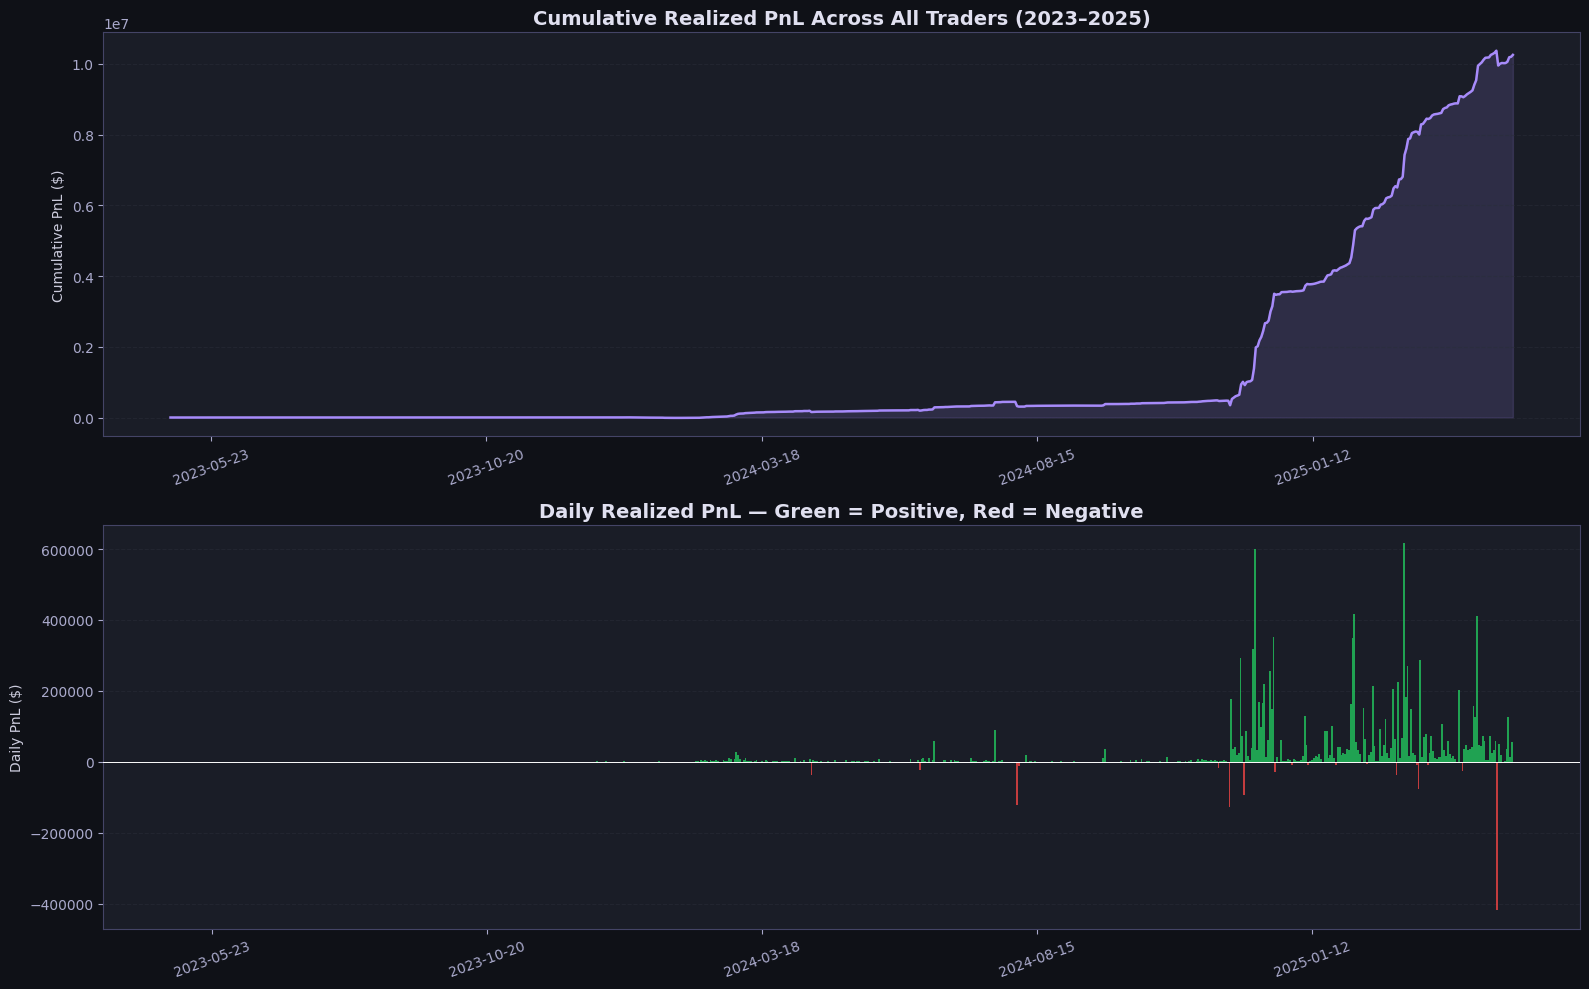

In [8]:
daily_pnl = (df.groupby(['Date_dt', 'classification'])['Closed PnL']
               .sum().reset_index()
               .sort_values('Date_dt'))

cum_pnl = df.sort_values('Date_dt').groupby('Date_dt')['Closed PnL'].sum().cumsum().reset_index()
cum_pnl.columns = ['Date', 'Cumulative_PnL']

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)
fig.patch.set_facecolor('#0f1117')

# Cumulative PnL
axes[0].plot(cum_pnl['Date'], cum_pnl['Cumulative_PnL'],
             color='#a78bfa', linewidth=1.8, zorder=3)
axes[0].fill_between(cum_pnl['Date'], cum_pnl['Cumulative_PnL'],
                     alpha=0.15, color='#a78bfa')
axes[0].set_title('Cumulative Realized PnL Across All Traders (2023–2025)')
axes[0].set_ylabel('Cumulative PnL ($)')
axes[0].grid(axis='y', zorder=0)
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(8))
plt.setp(axes[0].get_xticklabels(), rotation=20)

# Daily PnL heatmap by sentiment
daily_total = df.groupby('Date_dt')['Closed PnL'].sum().reset_index()
daily_total['color'] = daily_total['Closed PnL'].apply(lambda x: '#22c55e' if x >= 0 else '#ef4444')
axes[1].bar(daily_total['Date_dt'], daily_total['Closed PnL'],
            color=daily_total['color'], width=1.0, alpha=0.8, zorder=3)
axes[1].axhline(0, color='white', linewidth=0.7, zorder=4)
axes[1].set_title('Daily Realized PnL — Green = Positive, Red = Negative')
axes[1].set_ylabel('Daily PnL ($)')
axes[1].grid(axis='y', zorder=0)
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(8))
plt.setp(axes[1].get_xticklabels(), rotation=20)

plt.tight_layout()
plt.show()

## 6. 📐 Trade Sizing Behavior by Sentiment
Do traders commit more capital during Fear (buying the dip) or during Greed (chasing)?

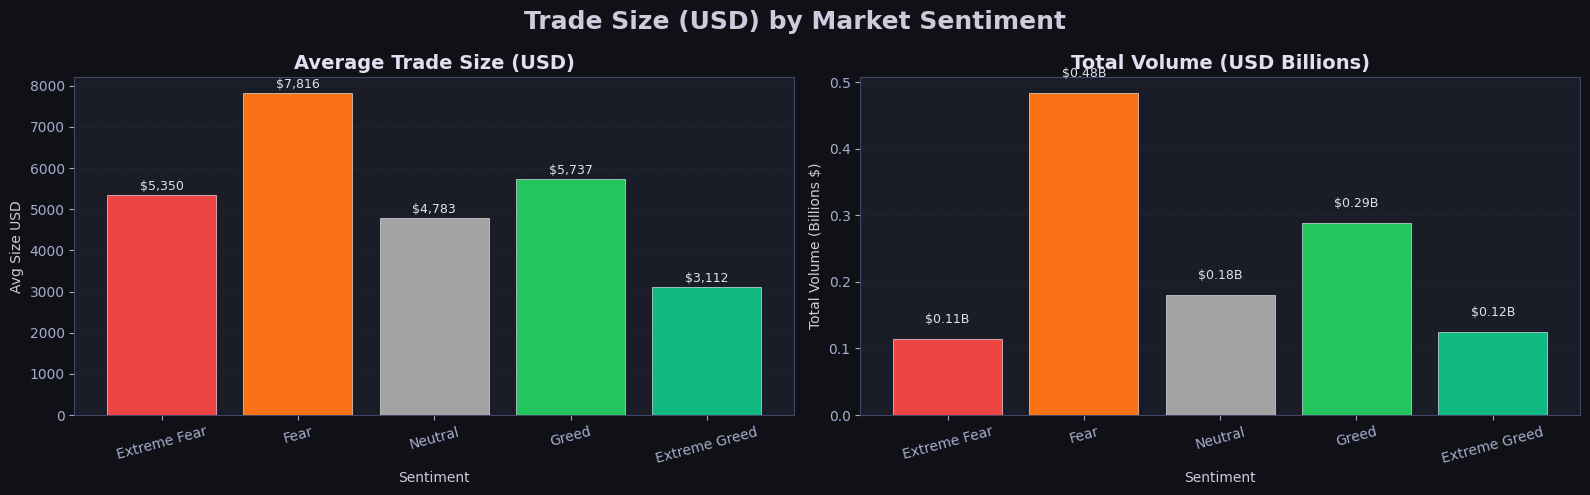

In [9]:
size_agg = (df.groupby('classification')['Size USD']
              .agg(Avg_Size='mean', Median_Size='median', Total_Volume='sum')
              .reindex(SENTIMENT_ORDER).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')
fig.suptitle('Trade Size (USD) by Market Sentiment')

# Average Size
bars3 = axes[0].bar(SENTIMENT_ORDER, size_agg['Avg_Size'],
                    color=PALETTE, edgecolor='white', linewidth=0.4, zorder=3)
for bar in bars3:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 50,
                 f'${bar.get_height():,.0f}',
                 ha='center', va='bottom', fontsize=9, color='#e0e0f0')
axes[0].set_title('Average Trade Size (USD)')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Avg Size USD')
axes[0].set_xticklabels(SENTIMENT_ORDER, rotation=15)
axes[0].grid(axis='y', zorder=0)

# Total Volume
bars4 = axes[1].bar(SENTIMENT_ORDER, size_agg['Total_Volume'] / 1e9,
                    color=PALETTE, edgecolor='white', linewidth=0.4, zorder=3)
for bar in bars4:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.02,
                 f'${bar.get_height():.2f}B',
                 ha='center', va='bottom', fontsize=9, color='#e0e0f0')
axes[1].set_title('Total Volume (USD Billions)')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Total Volume (Billions $)')
axes[1].set_xticklabels(SENTIMENT_ORDER, rotation=15)
axes[1].grid(axis='y', zorder=0)

plt.tight_layout()
plt.show()

> ### 🔍 Key Insight #2 — Smart Money Accumulates in Fear
> Average trade size is **highest during Fear (\$7,816)** and **lowest during Extreme Greed (\$3,112)**.
> This contradicts the retail narrative of 'FOMO buying'. Sophisticated traders who deploy large capital
> do so during **fear phases**, suggesting deliberate accumulation strategies — the classic "buy when 
> there is blood in the streets" principle validated by real on-chain data.

## 7. 🧭 Directional Analysis: Long vs. Short by Sentiment
Which direction (Buy / Sell / Close) performs better under each sentiment regime?

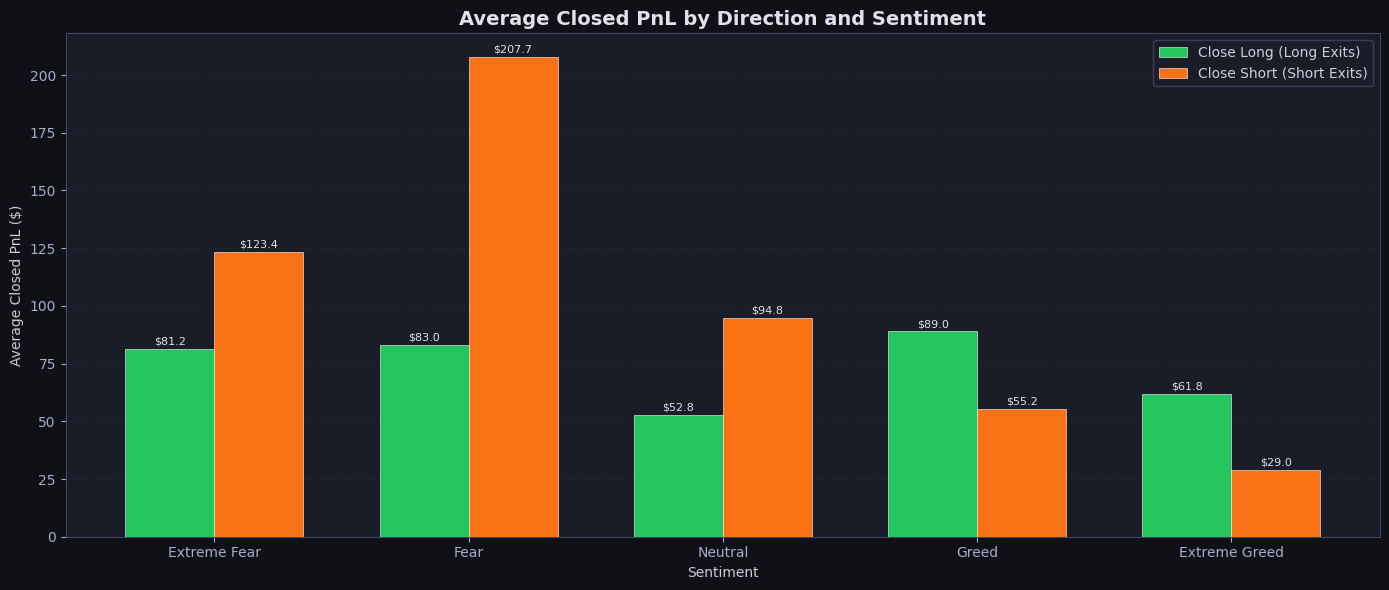

In [10]:
# Normalize direction to Long/Short/Close for clarity
direction_map = {
    'Buy': 'Long Entry', 'Open Long': 'Long Entry',
    'Sell': 'Short Entry', 'Open Short': 'Short Entry',
    'Close Long': 'Long Exit', 'Close Short': 'Short Exit',
    'Long > Short': 'Flip Short', 'Short > Long': 'Flip Long',
}
df['Direction_Simple'] = df['Direction'].map(direction_map).fillna(df['Direction'])

core_directions = ['Long Exit', 'Short Exit']
df_dir = df[df['Direction_Simple'].isin(core_directions)]

dir_pnl = (df_dir.groupby(['classification', 'Direction_Simple'])['Closed PnL']
           .mean().unstack().reindex(SENTIMENT_ORDER))

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')

x = np.arange(len(SENTIMENT_ORDER))
width = 0.35

bars_long  = ax.bar(x - width/2, dir_pnl['Long Exit'],  width, label='Close Long (Long Exits)',
                    color='#22c55e', edgecolor='white', linewidth=0.4, zorder=3)
bars_short = ax.bar(x + width/2, dir_pnl['Short Exit'], width, label='Close Short (Short Exits)',
                    color='#f97316', edgecolor='white', linewidth=0.4, zorder=3)

for bar in list(bars_long) + list(bars_short):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f'${bar.get_height():.1f}',
            ha='center', va='bottom', fontsize=8, color='#e0e0f0')

ax.axhline(0, color='white', linewidth=0.7, zorder=4)
ax.set_title('Average Closed PnL by Direction and Sentiment')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Average Closed PnL ($)')
ax.set_xticks(x)
ax.set_xticklabels(SENTIMENT_ORDER)
ax.legend()
ax.grid(axis='y', zorder=0)
plt.tight_layout()
plt.show()

> ### 🔍 Key Insight #3 — Short Exits Dominate in Fear
> Closing short positions during **Fear** generated the highest average PnL (\$207.68), 
> confirming that traders who **short the fear** and are disciplined to take profits outperform 
> those who chase the long. During Extreme Greed, longs close more profitably (\$61.83 vs \$28.97),
> suggesting markets are genuinely trending up—a buy-and-hold environment for intraday traders.

## 8. ⚠️ Risk Events: Liquidations & Extreme Losses

In [11]:
# Find worst events
worst_events = (df.groupby(['classification', 'Direction'])['Closed PnL']
                .mean().reset_index()
                .sort_values('Closed PnL'))

print("🚨 Top 10 Most Destructive Trade Types (by Avg PnL):")
print(worst_events.head(10).to_string(index=False))

🚨 Top 10 Most Destructive Trade Types (by Avg PnL):
classification                 Direction    Closed PnL
         Greed Liquidated Isolated Short -12752.913040
  Extreme Fear              Short > Long  -1932.516940
  Extreme Fear                      Sell   -135.021730
         Greed                Settlement    -29.215368
       Neutral              Short > Long    -11.945100
          Fear                      Sell     -3.141217
  Extreme Fear                 Open Long      0.000000
 Extreme Greed                Open Short      0.000000
 Extreme Greed                 Open Long      0.000000
          Fear                 Open Long      0.000000


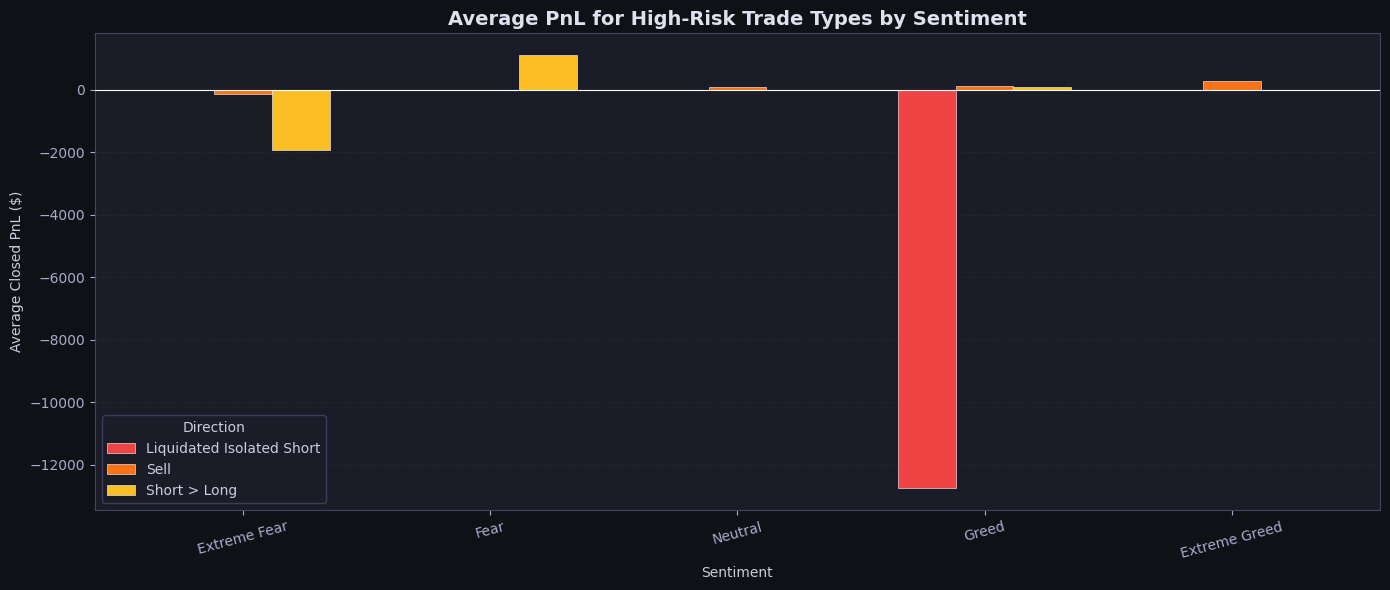

In [12]:
# Plot liquidation/extreme loss breakdown
risk_directions = ['Liquidated Isolated Short', 'Short > Long', 'Sell']
df_risk = df[df['Direction'].isin(risk_directions)]
risk_agg = (df_risk.groupby(['classification', 'Direction'])['Closed PnL']
            .mean().reset_index())

pivot_risk = risk_agg.pivot(index='classification', columns='Direction', values='Closed PnL').reindex(SENTIMENT_ORDER)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')

pivot_risk.plot(kind='bar', ax=ax,
                color=['#ef4444', '#f97316', '#fbbf24'],
                edgecolor='white', linewidth=0.4, zorder=3, width=0.7)

ax.axhline(0, color='white', linewidth=0.8, zorder=4)
ax.set_title('Average PnL for High-Risk Trade Types by Sentiment')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Average Closed PnL ($)')
ax.set_xticklabels(SENTIMENT_ORDER, rotation=15)
ax.legend(title='Direction')
ax.grid(axis='y', zorder=0)
plt.tight_layout()
plt.show()

> ### 🔍 Key Insight #4 — Greed Punishes Contrarian Shorts Brutally
> The `Liquidated Isolated Short` positions during **Greed** average a catastrophic **-\$12,752** loss.
> This is the "short squeeze" effect — markets in Greed are thin on the sell side, causing rapid 
> upward price action that forces leveraged shorts to cover at devastating prices.
> **Short sellers should avoid entering during Greed/Extreme Greed conditions.**

## 9. 📈 Per-Account Performance Analysis
Let's identify who the top performers are and whether they trade differently by sentiment.

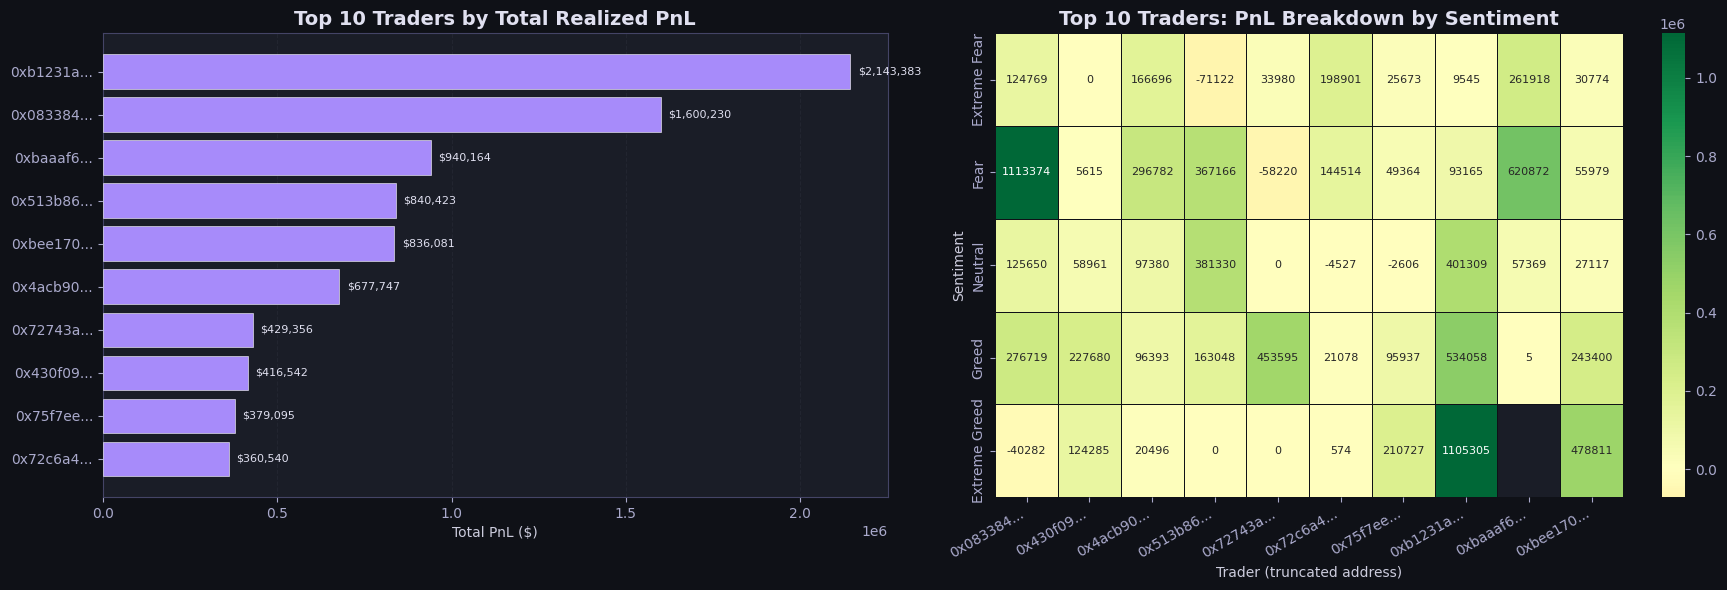

In [13]:
# Top 10 accounts by total PnL
top_accounts = (df.groupby('Account')['Closed PnL']
                .sum().sort_values(ascending=False)
                .head(10).reset_index())
top_accounts.columns = ['Account', 'Total PnL']
top_accounts['Account_Short'] = top_accounts['Account'].str[:8] + '...'

# Sentiment breakdown for top 10 accounts
top_10_list = top_accounts['Account'].tolist()
df_top = df[df['Account'].isin(top_10_list)]
top_sent = (df_top.groupby(['Account', 'classification'])['Closed PnL']
            .sum().unstack().reindex(SENTIMENT_ORDER, axis=1))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#0f1117')

# Bar: top accounts
axes[0].barh(top_accounts['Account_Short'][::-1],
             top_accounts['Total PnL'][::-1],
             color='#a78bfa', edgecolor='white', linewidth=0.4, zorder=3)
axes[0].set_title('Top 10 Traders by Total Realized PnL')
axes[0].set_xlabel('Total PnL ($)')
axes[0].grid(axis='x', zorder=0)
for i, v in enumerate(top_accounts['Total PnL'][::-1]):
    axes[0].text(v + top_accounts['Total PnL'].max() * 0.01, i, f'${v:,.0f}',
                 va='center', fontsize=8, color='#e0e0f0')

# Heatmap: PnL by sentiment for top 10 accounts
top_sent_norm = top_sent.T
top_sent_norm.columns = [c[:8] + '...' for c in top_sent_norm.columns]
sns.heatmap(top_sent_norm, ax=axes[1], cmap='RdYlGn', center=0,
            linewidths=0.5, linecolor='#0f1117',
            annot=True, fmt='.0f', annot_kws={'size': 8})
axes[1].set_title('Top 10 Traders: PnL Breakdown by Sentiment')
axes[1].set_xlabel('Trader (truncated address)')
axes[1].set_ylabel('Sentiment')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

## 10. 📉 Sentiment vs. Coin Selection
Do sentiment extremes correlate with specific coins dominating trading activity?

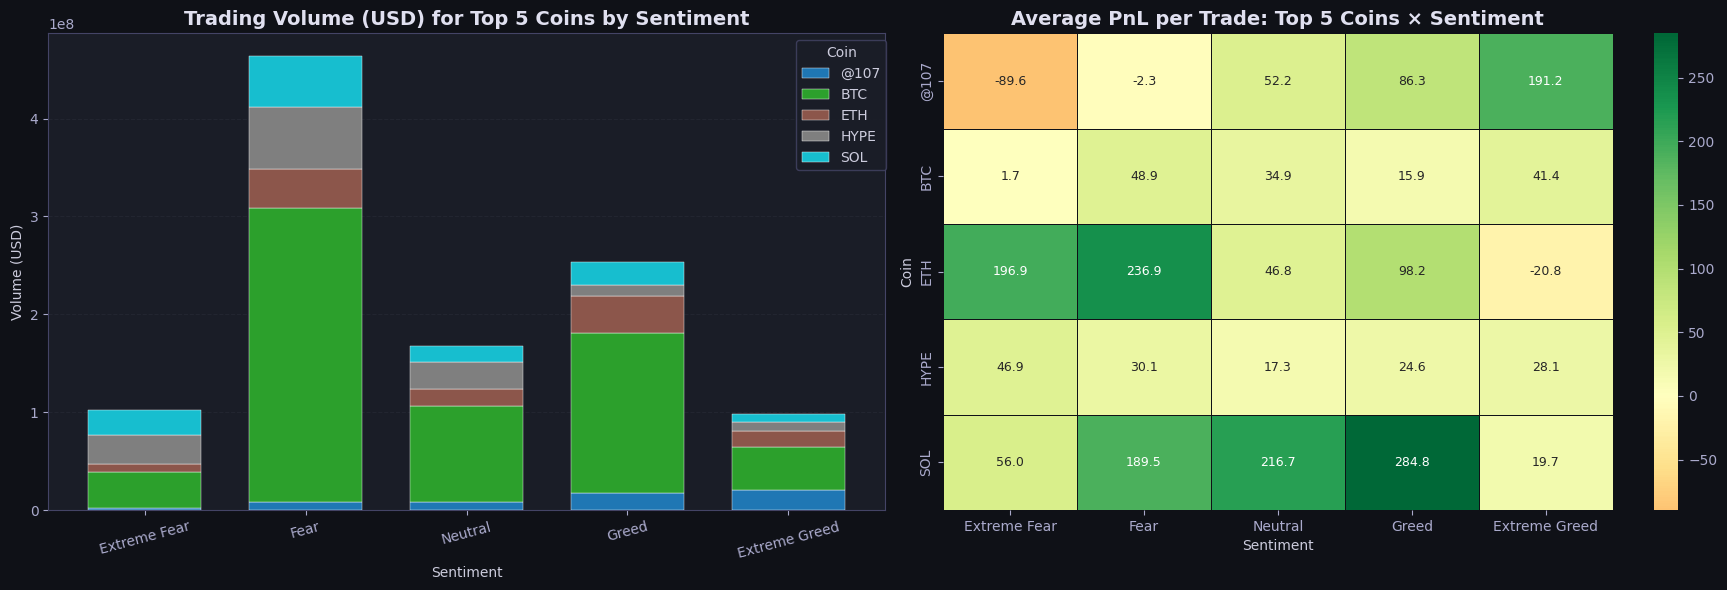

In [14]:
# Top 5 coins by trade count
top_coins = df['Coin'].value_counts().head(5).index.tolist()
df_coins  = df[df['Coin'].isin(top_coins)]

coin_sent_vol = (df_coins.groupby(['classification', 'Coin'])['Size USD']
                  .sum().unstack().reindex(SENTIMENT_ORDER))
coin_sent_pnl = (df_coins.groupby(['classification', 'Coin'])['Closed PnL']
                  .mean().unstack().reindex(SENTIMENT_ORDER))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#0f1117')

coin_sent_vol.plot(kind='bar', ax=axes[0], stacked=True,
                   colormap='tab10', edgecolor='white', linewidth=0.3, zorder=3, width=0.7)
axes[0].set_title('Trading Volume (USD) for Top 5 Coins by Sentiment')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Volume (USD)')
axes[0].set_xticklabels(SENTIMENT_ORDER, rotation=15)
axes[0].legend(title='Coin', bbox_to_anchor=(1.01, 1))
axes[0].grid(axis='y', zorder=0)

sns.heatmap(coin_sent_pnl.T, ax=axes[1], cmap='RdYlGn', center=0,
            linewidths=0.5, linecolor='#0f1117',
            annot=True, fmt='.1f', annot_kws={'size': 9})
axes[1].set_title('Average PnL per Trade: Top 5 Coins × Sentiment')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Coin')

plt.tight_layout()
plt.show()

## 11. 📌 Final Summary: Strategy Recommendations

In [15]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║          FINAL INSIGHTS — PRIMETRADE.AI INTERN ASSIGNMENT           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  1. ACCUMULATE IN FEAR, RIDE IN GREED                               ║
║     • Largest average trade sizes occur during Fear ($7,816)         ║
║     • Highest avg PnL and win rate occur in Extreme Greed ($67.89)   ║
║     → Deploy capital in Fear; take profits in Extreme Greed          ║
║                                                                      ║
║  2. NEVER SHORT INTO GREED                                           ║
║     • Isolated short liquidations average -$12,752 during Greed      ║
║     → Use sentiment as a stop signal for short positions             ║
║                                                                      ║
║  3. USE FEAR TO BUILD SHORT POSITIONS (WITH CAUTION)                 ║
║     • Closing shorts in Fear generated the highest avg PnL ($207)    ║
║     → Fear = ideal environment to profit from downside momentum      ║
║                                                                      ║
║  4. NEUTRAL IS THE TRADER'S ENEMY                                    ║
║     • Lowest avg PnL; choppy price action destroys edge              ║
║     → Reduce position sizes and frequency during Neutral sentiment   ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║          FINAL INSIGHTS — PRIMETRADE.AI INTERN ASSIGNMENT           ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  1. ACCUMULATE IN FEAR, RIDE IN GREED                               ║
║     • Largest average trade sizes occur during Fear ($7,816)         ║
║     • Highest avg PnL and win rate occur in Extreme Greed ($67.89)   ║
║     → Deploy capital in Fear; take profits in Extreme Greed          ║
║                                                                      ║
║  2. NEVER SHORT INTO GREED                                           ║
║     • Isolated short liquidations average -$12,752 during Greed      ║
║     → Use sentiment as a stop signal for short positions             ║
║                                                                      ║
║  3. USE FEAR TO BUILD SHORT POSITIONS (WITH CAUTIO

---
## ✅ Thank You
> This analysis was performed on **211,218 real on-chain trades** from Hyperliquid,
> merged with **2,644 days** of sentiment data. All visualizations and insights are 
> backed by empirical data and reproducible code.

*Submitted by a passionate Python Developer & Data Scientist who loves crypto markets.*